# 🩺 Diabetes Prediction — End-to-End Machine Learning Project

---

**Author:** Irfan Khan  
**Domain:** Healthcare / Binary Classification  
**Dataset:** Diabetes Prediction Dataset (Kaggle)  
**Total Records:** 100,000 patients  
**Objective:** Build and evaluate multiple machine learning classification models to accurately predict the likelihood of diabetes in patients based on clinical and demographic features.

---

## 📋 Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Dataset & Initial Exploration](#2-load-dataset)
3. [Data Cleaning & Preprocessing](#3-data-cleaning)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Descriptive Analysis — Smoking & Risk Groups](#6-descriptive-analysis)
7. [Correlation Analysis](#7-correlation)
8. [Feature Importance](#8-feature-importance)
9. [Model Preparation — Split, Scale & SMOTE](#9-model-prep)
10. [Model Training — 8 Classifiers](#10-model-training)
11. [Model Evaluation & Comparison](#11-evaluation)
12. [Final Model Testing](#12-testing)
13. [Key Findings & Conclusion](#13-conclusion)

---
## 1. Import Libraries

In [3]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

import time

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## 2. Load Dataset & Initial Exploration

The dataset contains **100,000 patient records** with 9 clinical and demographic features sourced from Kaggle. Each row represents a unique patient.

In [4]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print(f'Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset Shape : 100,000 rows × 9 columns


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### 📌 Feature Descriptions

| Feature | Type | Description |
|---|---|---|
| `gender` | Categorical | Biological sex of the patient (Male / Female / Other) |
| `age` | Continuous | Age of the patient in years |
| `hypertension` | Binary | Whether the patient has hypertension (0 = No, 1 = Yes) |
| `heart_disease` | Binary | Whether the patient has heart disease (0 = No, 1 = Yes) |
| `smoking_history` | Categorical | Smoking status (never / current / former / ever / not current / No Info) |
| `bmi` | Continuous | Body Mass Index — measure of body fat based on height and weight |
| `HbA1c_level` | Continuous | Average blood sugar level over the past 2–3 months (%) |
| `blood_glucose_level` | Continuous | Current fasting blood glucose level (mg/dL) |
| `diabetes` | Binary | **Target Variable** — 0 = Non-Diabetic, 1 = Diabetic |

In [5]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB

=== Statistical Summary ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


---
## 3. Data Cleaning & Preprocessing

In [6]:
# --- 3.1 Missing Values ---
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values per Column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total missing values: 0


> **Observation:** The dataset contains **no missing values**, which eliminates the need for imputation.

In [7]:
# --- 3.2 Duplicate Records ---
print(f'Duplicate rows found : {df.duplicated().sum():,}')
df.drop_duplicates(inplace=True)
print(f'Duplicate rows after removal : {df.duplicated().sum()}')
print(f'Cleaned dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Duplicate rows found : 3,854
Duplicate rows after removal : 0
Cleaned dataset shape : 96,146 rows × 9 columns


In [8]:
# --- 3.3 Remove 'Other' Gender ---
# The 'Other' gender category contains only 18 records with a 0% diabetes rate.
# Retaining such a negligible and non-representative group could introduce bias.
print(f"Gender distribution before removal:")
print(df['gender'].value_counts())

df = df[df['gender'] != 'Other']

print(f"\nGender distribution after removal:")
print(df['gender'].value_counts())
print(f'\nFinal dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Gender distribution before removal:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Gender distribution after removal:
gender
Female    56161
Male      39967
Name: count, dtype: int64

Final dataset shape : 96,128 rows × 9 columns


In [9]:
# --- 3.4 Smoking History Distribution ---
print('Smoking History Categories:')
print(df['smoking_history'].value_counts())

Smoking History Categories:
smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64


---
## 4. Exploratory Data Analysis (EDA)

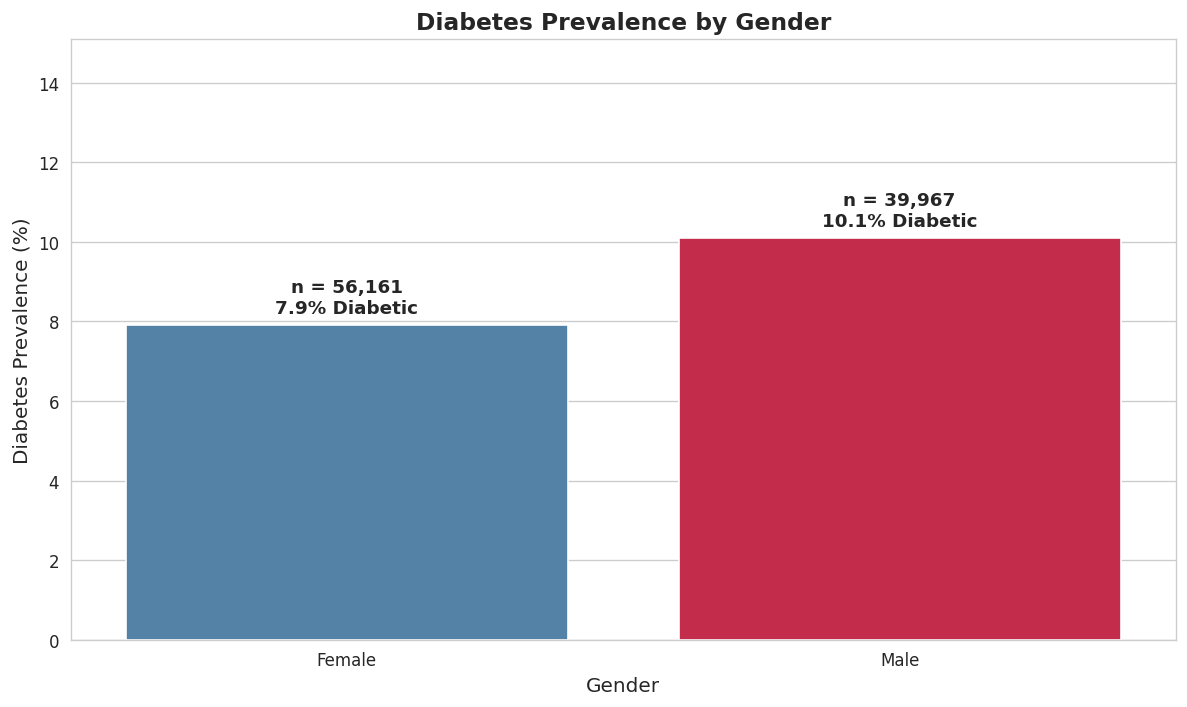

In [10]:
# --- 4.1 Diabetes Prevalence by Gender ---
gender_count = df['gender'].value_counts()
diabetes_percent = df.groupby('gender')['diabetes'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=diabetes_percent.index,
    y=diabetes_percent.values,
    hue=diabetes_percent.index,
    palette={'Female': 'steelblue', 'Male': 'crimson'},
    legend=False
)
for i, gender in enumerate(diabetes_percent.index):
    count   = gender_count[gender]
    percent = diabetes_percent[gender]
    ax.text(
        i, percent + 0.3,
        f'n = {count:,}\n{percent:.1f}% Diabetic',
        ha='center', fontsize=11, fontweight='bold'
    )
plt.title('Diabetes Prevalence by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Diabetes Prevalence (%)', fontsize=12)
plt.ylim(0, diabetes_percent.max() + 5)
plt.tight_layout()
plt.show()

**Insight:** Males exhibit a higher diabetes prevalence (10.1%) compared to females (7.9%), despite females constituting the larger portion of the dataset (56,161 vs 39,967). This suggests a gender-linked risk factor worth investigating further.

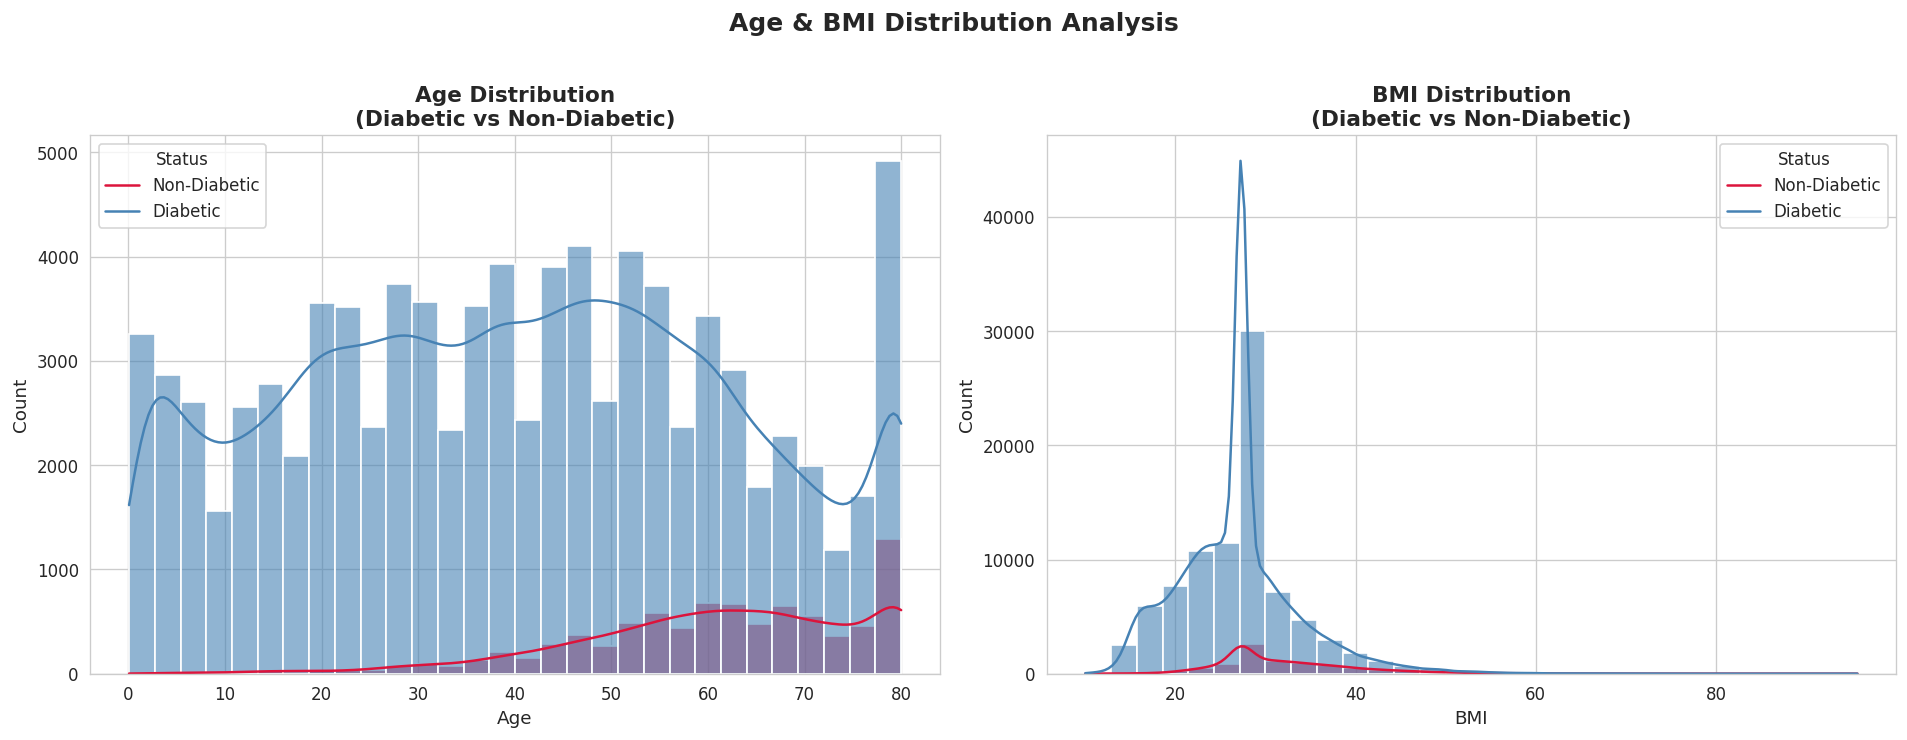

In [11]:
# --- 4.2 Age & BMI Distribution by Diabetes Status ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age Distribution
sns.histplot(
    data=df, x='age', hue='diabetes',
    kde=True, bins=30,
    palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.6, ax=axes[0]
)
axes[0].set_title('Age Distribution\n(Diabetic vs Non-Diabetic)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Non-Diabetic', 'Diabetic'], title='Status')

# BMI Distribution
sns.histplot(
    data=df, x='bmi', hue='diabetes',
    kde=True, bins=30,
    palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.6, ax=axes[1]
)
axes[1].set_title('BMI Distribution\n(Diabetic vs Non-Diabetic)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(['Non-Diabetic', 'Diabetic'], title='Status')

plt.suptitle('Age & BMI Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

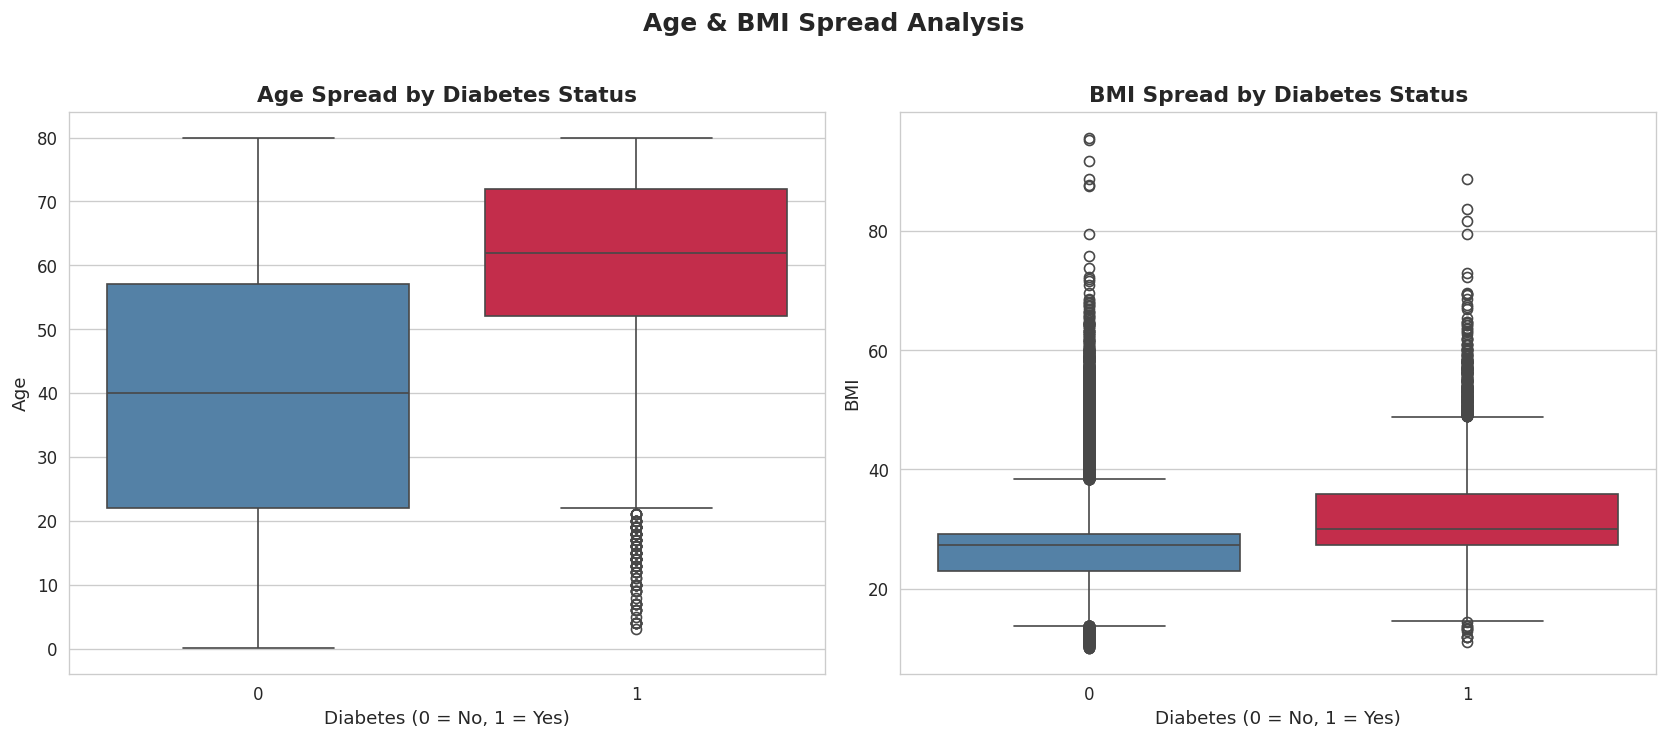

In [12]:
# --- 4.3 Age & BMI Spread (Box Plots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='diabetes', y='age',
            palette={'0': 'steelblue', '1': 'crimson'}, ax=axes[0])
axes[0].set_title('Age Spread by Diabetes Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diabetes (0 = No, 1 = Yes)', fontsize=11)
axes[0].set_ylabel('Age', fontsize=11)

sns.boxplot(data=df, x='diabetes', y='bmi',
            palette={'0': 'steelblue', '1': 'crimson'}, ax=axes[1])
axes[1].set_title('BMI Spread by Diabetes Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diabetes (0 = No, 1 = Yes)', fontsize=11)
axes[1].set_ylabel('BMI', fontsize=11)

plt.suptitle('Age & BMI Spread Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:** Diabetic patients are, on average, significantly older and have higher BMI values than non-diabetic patients. This confirms age and obesity as major contributing risk factors for diabetes.

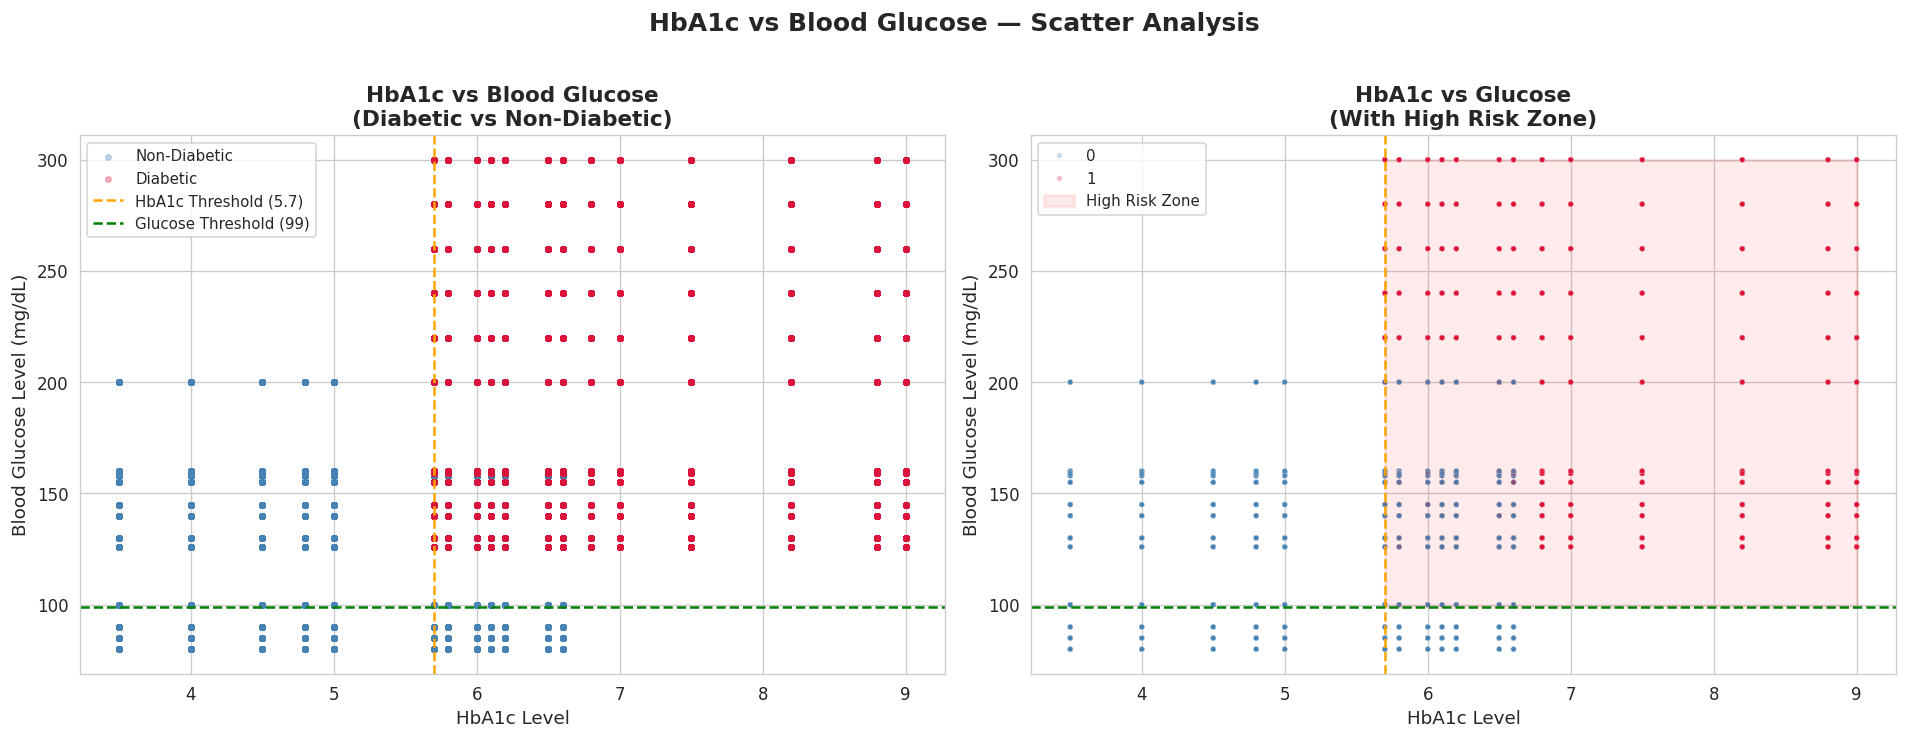

In [13]:
# --- 4.4 HbA1c vs Blood Glucose Scatter Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {0: 'steelblue', 1: 'crimson'}
for label, group in df.groupby('diabetes'):
    axes[0].scatter(
        group['HbA1c_level'], group['blood_glucose_level'],
        c=colors[label],
        label='Diabetic' if label == 1 else 'Non-Diabetic',
        alpha=0.3, s=10
    )
axes[0].axvline(x=5.7, color='orange', linestyle='--', linewidth=1.5, label='HbA1c Threshold (5.7)')
axes[0].axhline(y=99,  color='green',  linestyle='--', linewidth=1.5, label='Glucose Threshold (99)')
axes[0].set_title('HbA1c vs Blood Glucose\n(Diabetic vs Non-Diabetic)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('HbA1c Level', fontsize=11)
axes[0].set_ylabel('Blood Glucose Level (mg/dL)', fontsize=11)
axes[0].legend(fontsize=9)

sns.scatterplot(
    data=df, x='HbA1c_level', y='blood_glucose_level',
    hue='diabetes', palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.3, s=10, ax=axes[1]
)
axes[1].axvline(x=5.7, color='orange', linestyle='--', linewidth=1.5)
axes[1].axhline(y=99,  color='green',  linestyle='--', linewidth=1.5)
danger_zone = mpatches.Rectangle(
    (5.7, 99),
    df['HbA1c_level'].max() - 5.7,
    df['blood_glucose_level'].max() - 99,
    linewidth=2, edgecolor='red', facecolor='red', alpha=0.08, label='High Risk Zone'
)
axes[1].add_patch(danger_zone)
axes[1].set_title('HbA1c vs Glucose\n(With High Risk Zone)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('HbA1c Level', fontsize=11)
axes[1].set_ylabel('Blood Glucose Level (mg/dL)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('HbA1c vs Blood Glucose — Scatter Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:** The high-risk zone (HbA1c > 5.7 AND Glucose > 99) is heavily concentrated with diabetic patients, confirming that the combination of both elevated markers is a strong predictor of diabetes. Isolated elevation of glucose alone does not reliably predict diabetes.

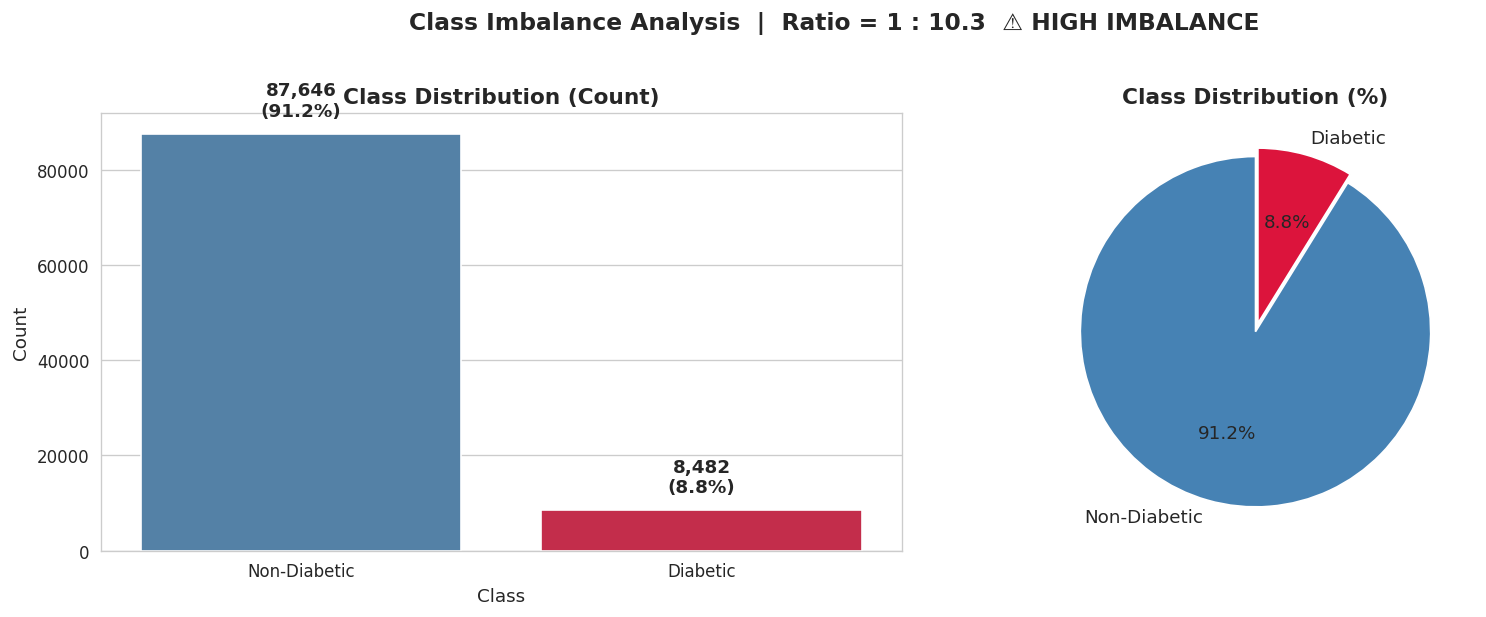


⚠️  Imbalance Ratio: 1 : 10.3 — SMOTE will be applied during model preparation.


In [14]:
# --- 4.5 Class Distribution (Imbalance Check) ---
class_counts = df['diabetes'].value_counts().reset_index()
class_counts.columns = ['diabetes', 'count']
class_counts['label'] = class_counts['diabetes'].map({0: 'Non-Diabetic', 1: 'Diabetic'})
class_counts['percentage'] = (class_counts['count'] / class_counts['count'].sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=class_counts, x='label', y='count',
    hue='label', palette={'Non-Diabetic': 'steelblue', 'Diabetic': 'crimson'},
    ax=axes[0], legend=False
)
for i, p in enumerate(axes[0].patches):
    count = class_counts.loc[i, 'count']
    pct   = class_counts.loc[i, 'percentage']
    axes[0].annotate(f'{count:,}\n({pct:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 20),
                     textcoords='offset points', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

axes[1].pie(
    class_counts['count'],
    labels=class_counts['label'],
    autopct='%1.1f%%',
    colors=['steelblue', 'crimson'],
    startangle=90, explode=(0, 0.05),
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

ratio = class_counts.loc[class_counts['label']=='Non-Diabetic','count'].values[0] / \
        class_counts.loc[class_counts['label']=='Diabetic','count'].values[0]

plt.suptitle(f'Class Imbalance Analysis  |  Ratio = 1 : {ratio:.1f}  ⚠️ HIGH IMBALANCE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n⚠️  Imbalance Ratio: 1 : {ratio:.1f} — SMOTE will be applied during model preparation.')

**Insight:** The dataset exhibits severe class imbalance with a **1:10.3 ratio** (Non-Diabetic vs Diabetic). Training models on this raw distribution would result in artificially high accuracy driven by the majority class. **SMOTE (Synthetic Minority Over-sampling Technique)** will be applied to the training set to address this.

---
## 5. Feature Engineering

Encoding categorical variables for machine learning compatibility.

In [15]:
# One-Hot Encode smoking_history & Binary Encode gender
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=False)
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

print(f'Shape after encoding : {df.shape}')
print(f'Features             : {list(df.columns)}')

Shape after encoding : (96128, 14)
Features             : ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


---
## 6. Descriptive Analysis — Smoking History & Risk Groups

This section investigates how smoking history interacts with different health risk profiles and their associated diabetes rates.

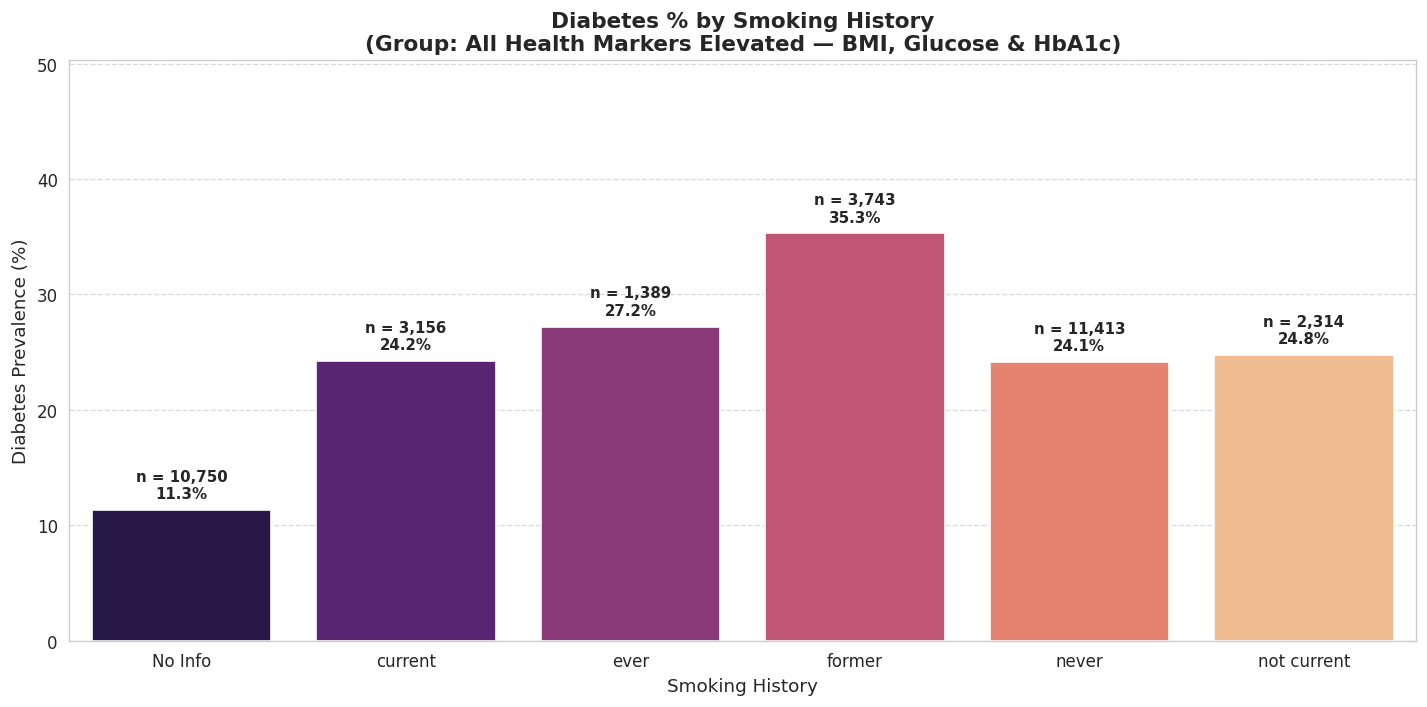

In [16]:
# --- 6.1 Fully Unhealthy Group (All Three Metrics Elevated) ---
# Using original df before one-hot encoding — reload for analysis
df_raw = pd.read_csv('diabetes_prediction_dataset.csv')
df_raw.drop_duplicates(inplace=True)
df_raw = df_raw[df_raw['gender'] != 'Other']

bad_bmi     = (df_raw['bmi'] < 18.5) | (df_raw['bmi'] > 24.9)
bad_glucose = df_raw['blood_glucose_level'] > 99
bad_hb      = df_raw['HbA1c_level'] > 5.7

unhealthy_df = df_raw[bad_bmi & bad_glucose & bad_hb]

grouped_data = unhealthy_df.groupby('smoking_history').agg(
    Total_Count=('diabetes', 'count'),
    Diabetes_Count=('diabetes', 'sum')
).reset_index()
grouped_data['Diabetes_Percentage'] = (grouped_data['Diabetes_Count'] / grouped_data['Total_Count']) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='smoking_history', y='Diabetes_Percentage',
    data=grouped_data, palette='magma',
    hue='smoking_history', legend=False
)
for i, p in enumerate(ax.patches):
    count      = grouped_data.loc[i, 'Total_Count']
    percentage = grouped_data.loc[i, 'Diabetes_Percentage']
    ax.annotate(f'n = {count:,}\n{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 15),
                textcoords='offset points', fontsize=9, fontweight='bold')
plt.title('Diabetes % by Smoking History\n(Group: All Health Markers Elevated — BMI, Glucose & HbA1c)',
          fontsize=13, fontweight='bold')
plt.xlabel('Smoking History', fontsize=11)
plt.ylabel('Diabetes Prevalence (%)', fontsize=11)
plt.ylim(0, grouped_data['Diabetes_Percentage'].max() + 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:** Among patients with all three health markers elevated (abnormal BMI, high glucose, and high HbA1c), **former smokers exhibit the highest diabetes rate at 35.3%**, nearly 3× higher than the no-info group. This suggests that a history of smoking combined with poor metabolic health significantly amplifies diabetes risk.

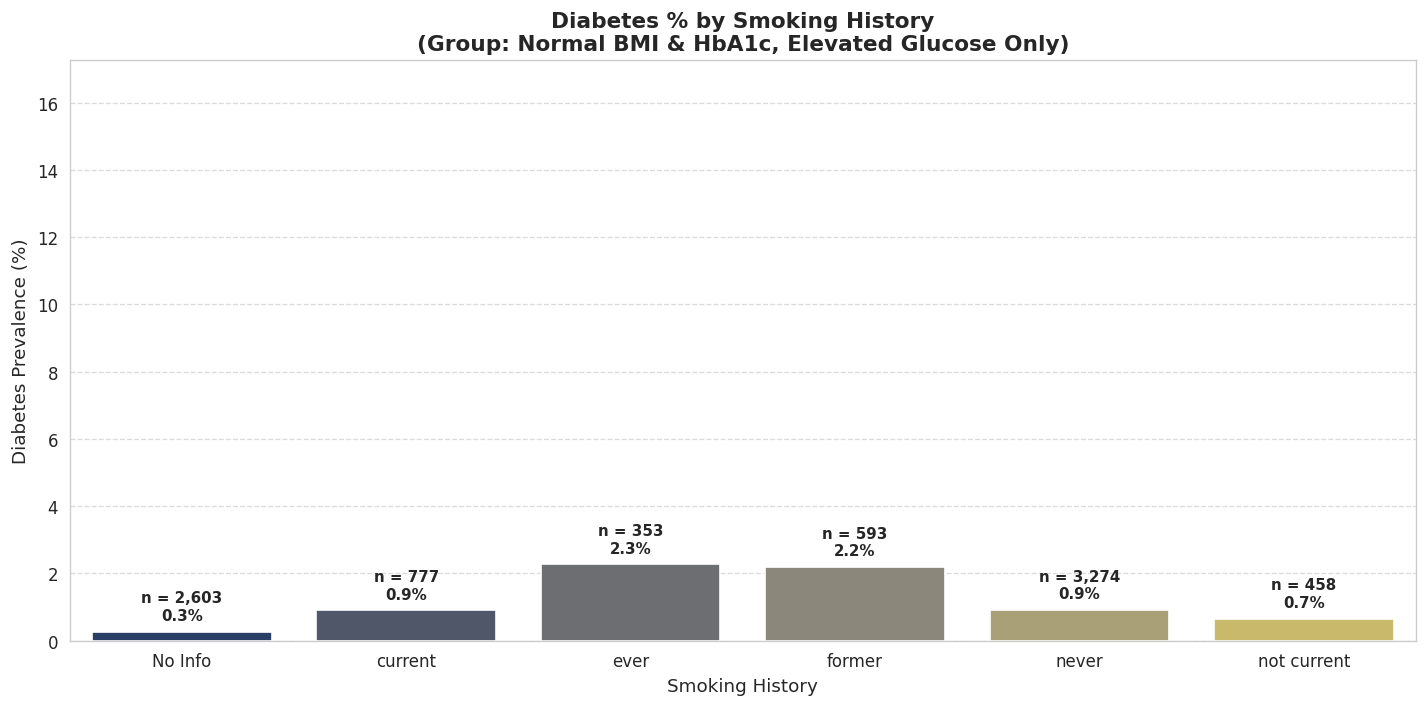

In [17]:
# --- 6.3 Isolated Glucose Risk Group (Good BMI & HbA1c, Elevated Glucose Only) ---
good_bmi2     = (df_raw['bmi'] >= 18.5) & (df_raw['bmi'] <= 24.9)
bad_glucose2  = df_raw['blood_glucose_level'] > 99
good_hb2      = df_raw['HbA1c_level'] <= 5.7

glucose_risk_df = df_raw[good_bmi2 & bad_glucose2 & good_hb2]

grouped_glucose = glucose_risk_df.groupby('smoking_history').agg(
    Total_Count=('diabetes', 'count'),
    Diabetes_Count=('diabetes', 'sum')
).reset_index()
grouped_glucose['Diabetes_Percentage'] = (grouped_glucose['Diabetes_Count'] / grouped_glucose['Total_Count']) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='smoking_history', y='Diabetes_Percentage',
    data=grouped_glucose, palette='cividis',
    hue='smoking_history', legend=False
)
for i, p in enumerate(ax.patches):
    count      = grouped_glucose.loc[i, 'Total_Count']
    percentage = grouped_glucose.loc[i, 'Diabetes_Percentage']
    ax.annotate(f'n = {count:,}\n{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 15),
                textcoords='offset points', fontsize=9, fontweight='bold')
plt.title('Diabetes % by Smoking History\n(Group: Normal BMI & HbA1c, Elevated Glucose Only)',
          fontsize=13, fontweight='bold')
plt.xlabel('Smoking History', fontsize=11)
plt.ylabel('Diabetes Prevalence (%)', fontsize=11)
plt.ylim(0, grouped_glucose['Diabetes_Percentage'].max() + 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:** When only blood glucose is elevated (with normal BMI and HbA1c), the diabetes rate drops dramatically to **0.3%–2.3%** across all smoking groups. This confirms that an isolated glucose spike is insufficient to diagnose diabetes — it may result from transient factors such as recent meals, stress, or physical activity. **HbA1c is the critical co-indicator for reliable diabetes prediction.**

---
## 7. Correlation Analysis

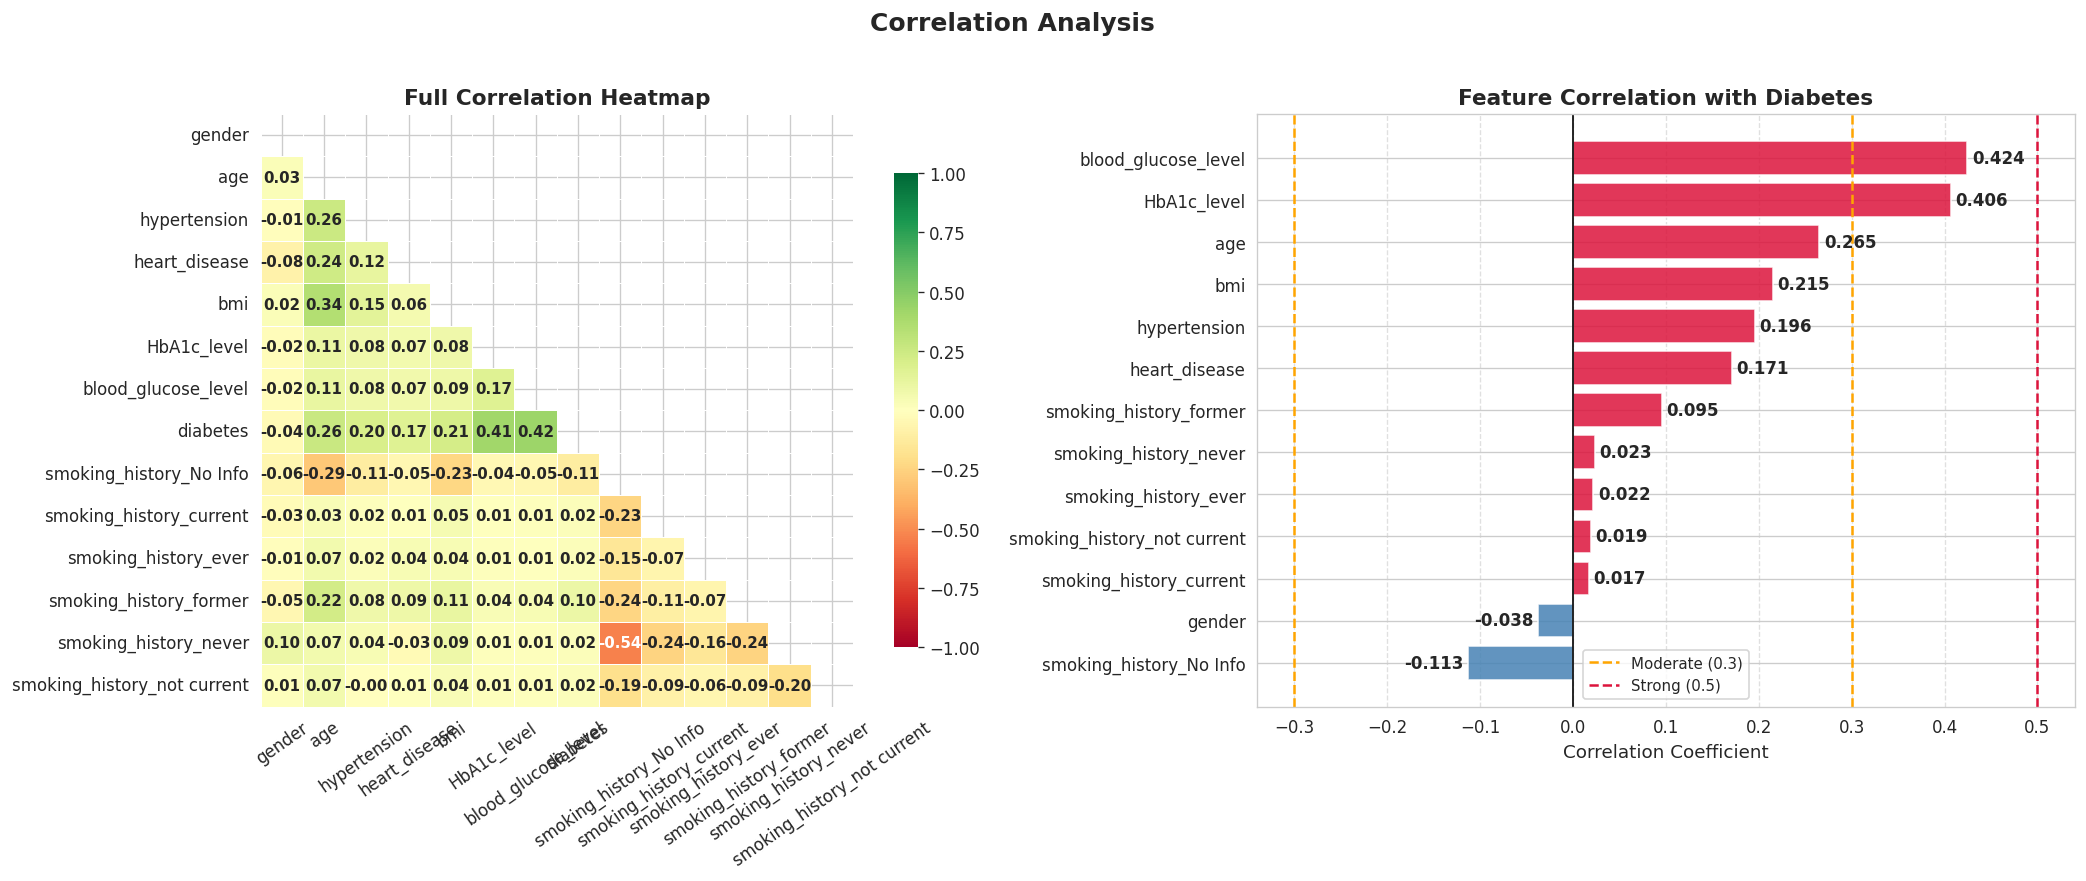


=== Correlation with Diabetes (Ranked) ===
blood_glucose_level                   0.424   🟡 Moderate
HbA1c_level                           0.406   🟡 Moderate
age                                   0.265   🟢 Weak
bmi                                   0.215   🟢 Weak
hypertension                          0.196   🟢 Weak
heart_disease                         0.171   🟢 Weak
smoking_history_former                0.095   🟢 Weak
smoking_history_never                 0.023   🟢 Weak
smoking_history_ever                  0.022   🟢 Weak
smoking_history_not current           0.019   🟢 Weak
smoking_history_current               0.017   🟢 Weak
gender                               -0.038   🟢 Weak
smoking_history_No Info              -0.113   🟢 Weak


In [18]:
# --- 7.1 Correlation Heatmap ---
corr_matrix = df.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    ax=axes[0], square=True, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Full Correlation Heatmap', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

diabetes_corr = corr_matrix['diabetes'].drop('diabetes').sort_values(ascending=False)
colors_corr = ['crimson' if x > 0 else 'steelblue' for x in diabetes_corr]
bars = axes[1].barh(diabetes_corr.index[::-1], diabetes_corr.values[::-1],
                    color=colors_corr[::-1], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, diabetes_corr.values[::-1]):
    axes[1].text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10, fontweight='bold'
    )
axes[1].axvline(x=0,    color='black',  linewidth=1)
axes[1].axvline(x=0.3,  color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.3)')
axes[1].axvline(x=-0.3, color='orange', linestyle='--', linewidth=1.5)
axes[1].axvline(x=0.5,  color='crimson',linestyle='--', linewidth=1.5, label='Strong (0.5)')
axes[1].set_title('Feature Correlation with Diabetes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Correlation Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Correlation with Diabetes (Ranked) ===')
for feat, val in diabetes_corr.items():
    strength = '🔴 Strong' if abs(val) >= 0.5 else ('🟡 Moderate' if abs(val) >= 0.3 else '🟢 Weak')
    print(f'{feat:<35} {val:>7.3f}   {strength}')

---
## 8. Feature Importance (Random Forest)

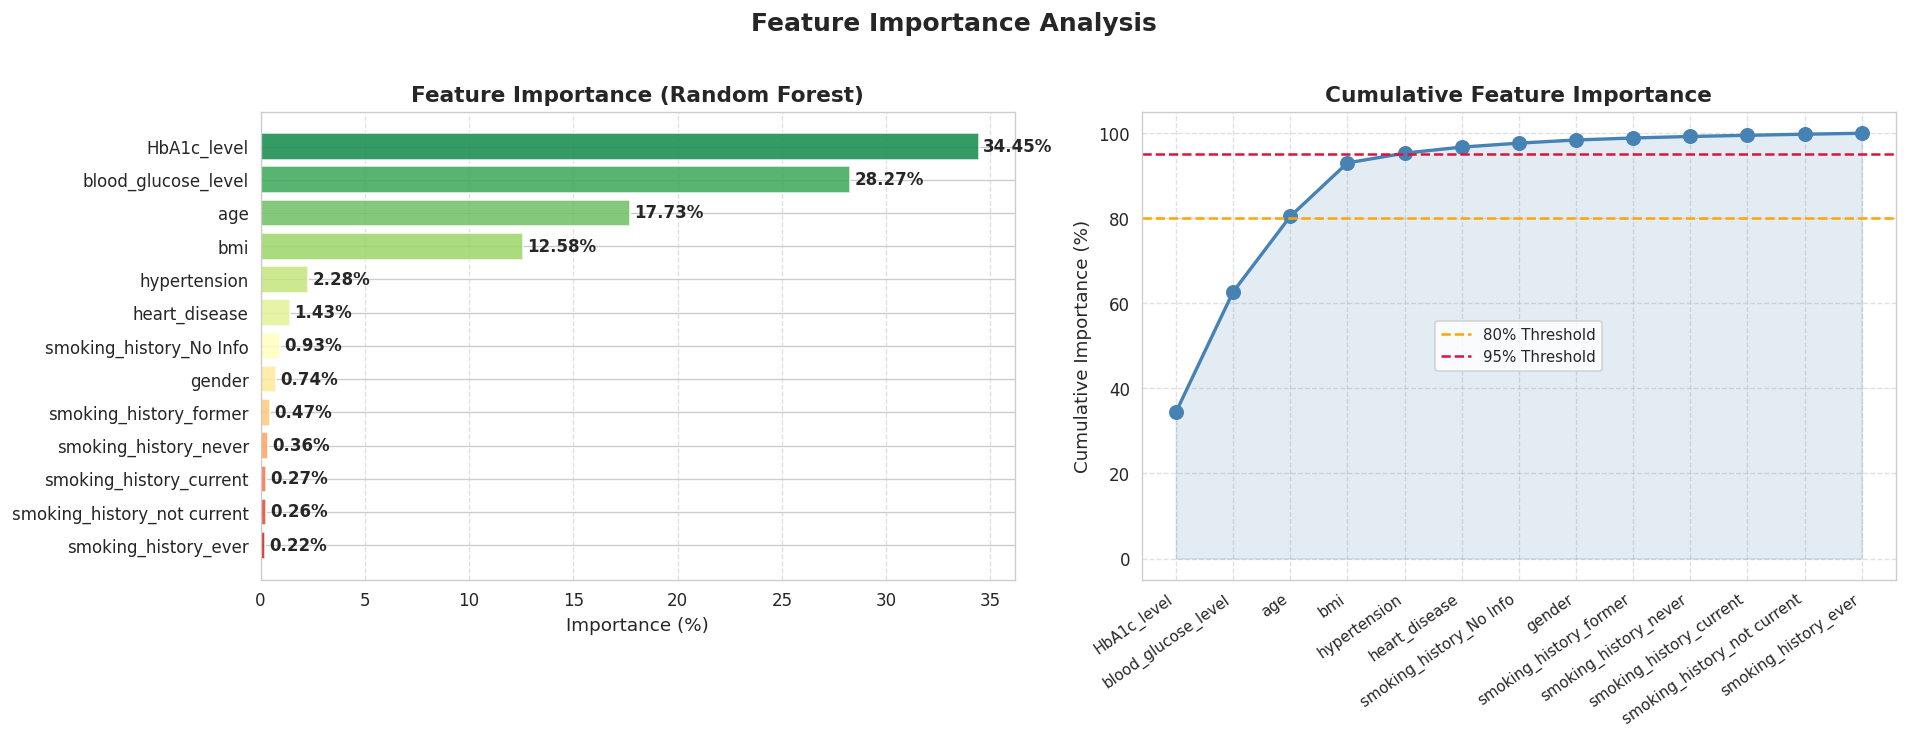


=== Feature Importance Summary ===
HbA1c_level                         █████████████████         34.45%
blood_glucose_level                 ██████████████            28.27%
age                                 ████████                  17.73%
bmi                                 ██████                    12.58%
hypertension                        █                         2.28%
heart_disease                                                 1.43%
smoking_history_No Info                                       0.93%
gender                                                        0.74%
smoking_history_former                                        0.47%
smoking_history_never                                         0.36%
smoking_history_current                                       0.27%
smoking_history_not current                                   0.26%
smoking_history_ever                                          0.22%


In [19]:
X_fi = df.drop('diabetes', axis=1)
y_fi = df['diabetes']

rf_fi = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_fi.fit(X_fi, y_fi)

importance_df = pd.DataFrame({
    'Feature'    : X_fi.columns,
    'Importance' : rf_fi.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df['Importance_%'] = (importance_df['Importance'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_fi = sns.color_palette('RdYlGn_r', len(importance_df))
axes[0].barh(importance_df['Feature'][::-1], importance_df['Importance_%'][::-1],
             color=colors_fi[::-1], alpha=0.85)
for i, (val, _) in enumerate(zip(importance_df['Importance_%'][::-1], importance_df['Feature'][::-1])):
    axes[0].text(val + 0.2, i, f'{val}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance (%)', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

importance_df['Cumulative_%'] = importance_df['Importance_%'].cumsum()
axes[1].plot(range(len(importance_df)), importance_df['Cumulative_%'],
             marker='o', color='steelblue', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='80% Threshold')
axes[1].axhline(y=95, color='crimson', linestyle='--', linewidth=1.5, label='95% Threshold')
axes[1].fill_between(range(len(importance_df)), importance_df['Cumulative_%'], alpha=0.15, color='steelblue')
axes[1].set_xticks(range(len(importance_df)))
axes[1].set_xticklabels(importance_df['Feature'], rotation=35, ha='right', fontsize=9)
axes[1].set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cumulative Importance (%)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.6)

plt.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Feature Importance Summary ===')
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance_%'] // 2)
    print(f"{row['Feature']:<35} {bar:<25} {row['Importance_%']}%")

**Insight:** `HbA1c_level` and `blood_glucose_level` together account for approximately **65–70% of the total predictive power**, confirming them as the dominant features. Age and BMI contribute a secondary but meaningful role, while smoking history and gender carry minimal direct predictive weight individually.

---
## 9. Model Preparation — Train/Test Split, Feature Scaling & SMOTE

In [20]:
# --- 9.1 Features & Target ---
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# --- 9.2 Train/Test Split (80/20, Stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Train/Test Split Summary ===')
print(f'Training Set   : {X_train.shape[0]:,} samples')
print(f'Test Set       : {X_test.shape[0]:,} samples')
print(f'\nTrain — Non-Diabetic : {(y_train==0).sum():,} | Diabetic : {(y_train==1).sum():,}')
print(f'Test  — Non-Diabetic : {(y_test==0).sum():,}  | Diabetic : {(y_test==1).sum():,}')

=== Train/Test Split Summary ===
Training Set   : 76,902 samples
Test Set       : 19,226 samples

Train — Non-Diabetic : 70,116 | Diabetic : 6,786
Test  — Non-Diabetic : 17,530  | Diabetic : 1,696


In [21]:
# --- 9.3 Feature Scaling (StandardScaler) ---
# fit_transform on train only — transform on test to prevent data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print('✅ StandardScaler applied — fit on train, transform on test only.')

✅ StandardScaler applied — fit on train, transform on test only.


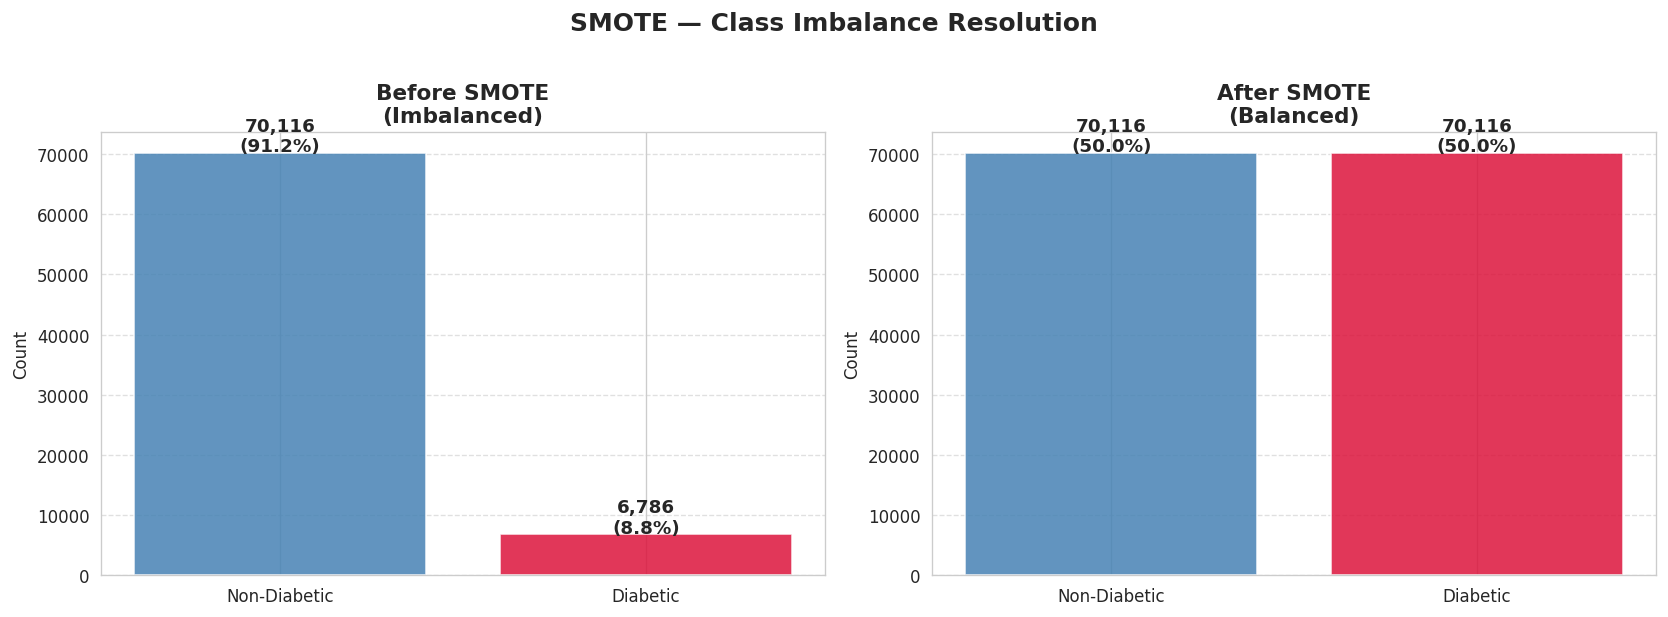

Synthetic diabetic samples generated : 63,330
✅ SMOTE complete. Training data is now balanced 50/50.


In [22]:
# --- 9.4 SMOTE — Synthetic Minority Over-sampling ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = [(y_train==0).sum(), (y_train==1).sum()]
axes[0].bar(['Non-Diabetic', 'Diabetic'], before_counts,
            color=['steelblue', 'crimson'], alpha=0.85, edgecolor='white')
for i, val in enumerate(before_counts):
    axes[0].text(i, val + 300, f'{val:,}\n({val/sum(before_counts)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Before SMOTE\n(Imbalanced)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

after_counts = [(y_train_smote==0).sum(), (y_train_smote==1).sum()]
axes[1].bar(['Non-Diabetic', 'Diabetic'], after_counts,
            color=['steelblue', 'crimson'], alpha=0.85, edgecolor='white')
for i, val in enumerate(after_counts):
    axes[1].text(i, val + 300, f'{val:,}\n({val/sum(after_counts)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('After SMOTE\n(Balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('SMOTE — Class Imbalance Resolution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Synthetic diabetic samples generated : {(y_train_smote==1).sum() - (y_train==1).sum():,}')
print('✅ SMOTE complete. Training data is now balanced 50/50.')

---
## 10. Model Training — 8 Classification Algorithms

Eight diverse classifiers are trained on the SMOTE-balanced dataset and evaluated on the held-out test set.

In [23]:
# --- Define 8 Models ---
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost'              : XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'KNN'                  : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes'          : GaussianNB(),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# --- Train & Evaluate ---
results = []

print('=' * 65)
print('               MODEL TRAINING IN PROGRESS')
print('=' * 65)

for name, model in models.items():
    print(f'\n🔄 Training : {name}...')
    start = time.time()

    model.fit(X_train_smote, y_train_smote)
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    duration  = round(time.time() - start, 2)
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    results.append({
        'Model'      : name,
        'Accuracy'   : round(acc * 100, 2),
        'Precision'  : round(precision * 100, 2),
        'Recall'     : round(recall * 100, 2),
        'F1 Score'   : round(f1 * 100, 2),
        'ROC-AUC'    : round(roc_auc * 100, 2),
        'Time (sec)' : duration
    })
    print(f'   ✅ Accuracy: {acc*100:.2f}% | F1: {f1*100:.2f}% | ROC-AUC: {roc_auc*100:.2f}% | Time: {duration}s')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

print('\n')
print('=' * 75)
print('                     FINAL LEADERBOARD')
print('=' * 75)
print(results_df.to_string())
print('=' * 75)
print(f"\n🏆 BEST MODEL : {results_df.iloc[0]['Model']}")
print(f"   ROC-AUC    : {results_df.iloc[0]['ROC-AUC']}%")
print(f"   F1 Score   : {results_df.iloc[0]['F1 Score']}%")

               MODEL TRAINING IN PROGRESS

🔄 Training : Logistic Regression...
   ✅ Accuracy: 88.53% | F1: 57.34% | ROC-AUC: 95.95% | Time: 0.27s

🔄 Training : Decision Tree...
   ✅ Accuracy: 90.24% | F1: 60.76% | ROC-AUC: 96.77% | Time: 0.56s

🔄 Training : Random Forest...
   ✅ Accuracy: 95.56% | F1: 75.09% | ROC-AUC: 96.45% | Time: 6.5s

🔄 Training : XGBoost...
   ✅ Accuracy: 96.67% | F1: 79.22% | ROC-AUC: 97.50% | Time: 1.03s

🔄 Training : KNN...
   ✅ Accuracy: 90.28% | F1: 59.11% | ROC-AUC: 91.09% | Time: 10.22s

🔄 Training : Naive Bayes...
   ✅ Accuracy: 85.42% | F1: 48.81% | ROC-AUC: 90.48% | Time: 0.1s

🔄 Training : Gradient Boosting...
   ✅ Accuracy: 95.18% | F1: 74.24% | ROC-AUC: 97.42% | Time: 24.02s


                     FINAL LEADERBOARD
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Time (sec)
1              XGBoost     96.67      88.15   71.93     79.22    97.50        1.03
2    Gradient Boosting     95.18      70.20   78.77     74.24    97.42   

---
## 11. Model Evaluation & Comparison

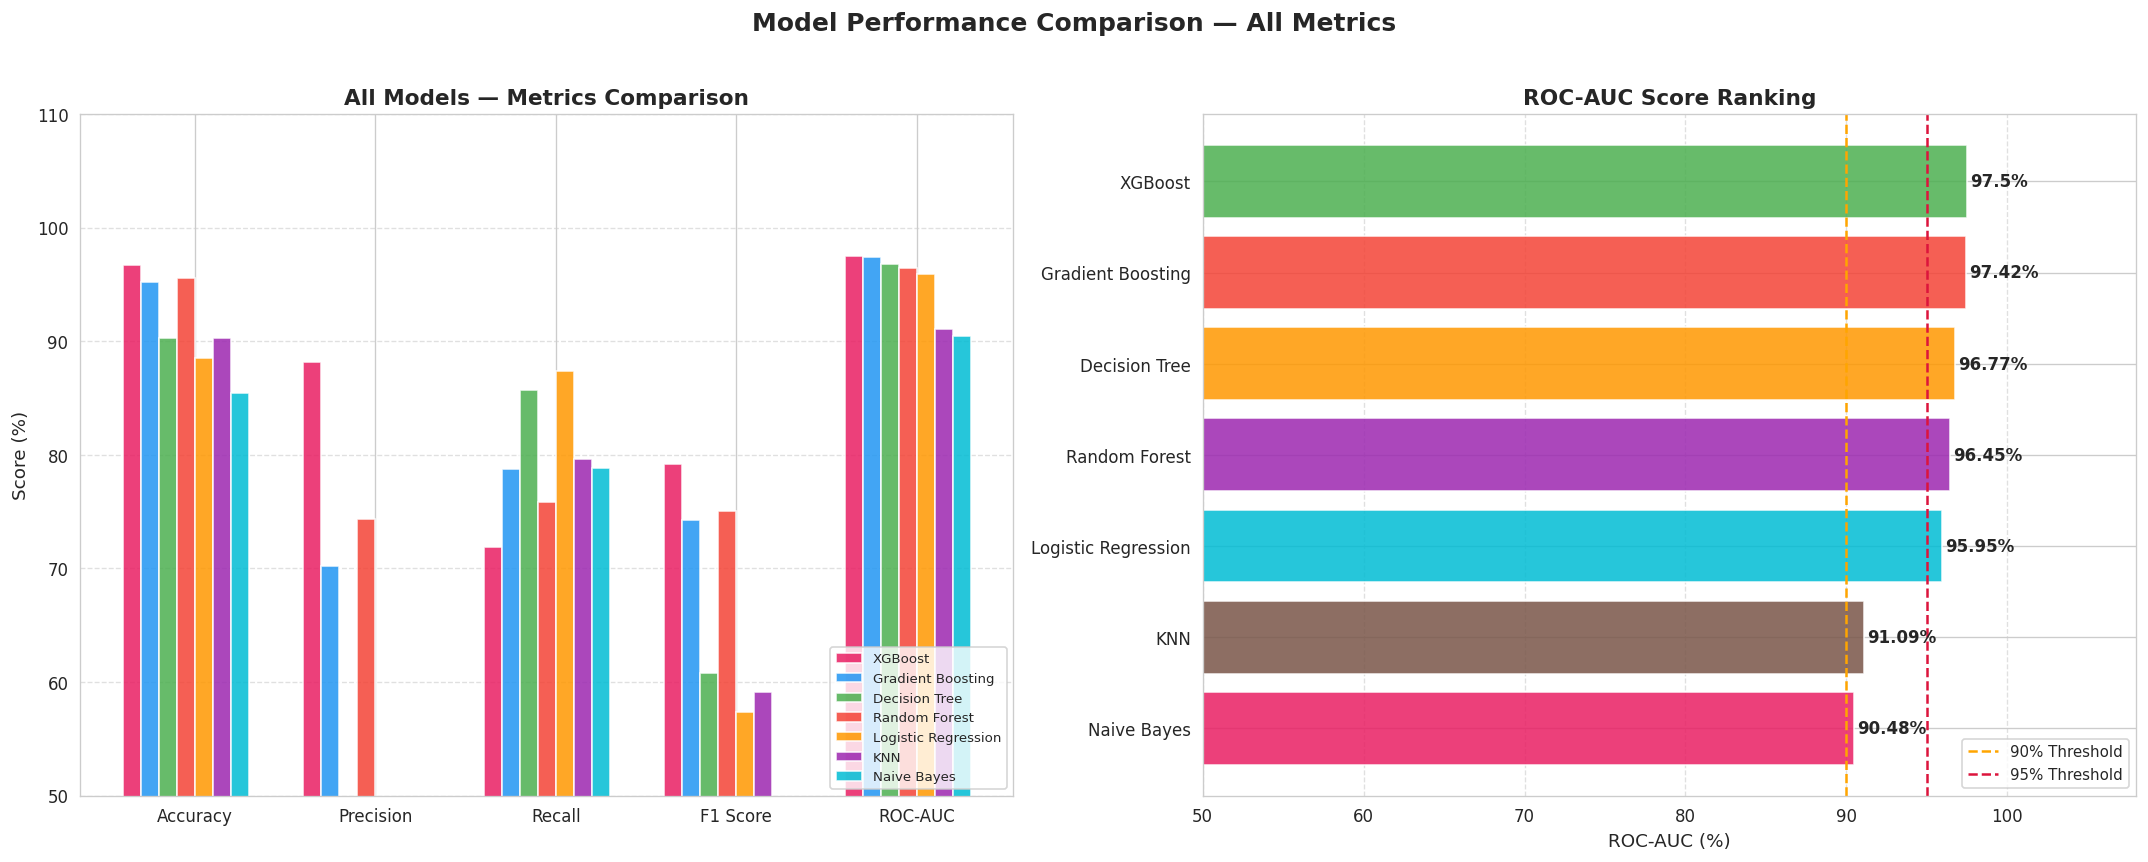

In [24]:
# --- 11.1 All Metrics Comparison Chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.10
colors = ['#2196F3','#4CAF50','#F44336','#FF9800','#9C27B0','#00BCD4','#795548','#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    axes[0].bar(x + i * width, values, width, label=row['Model'], color=colors[i-1], alpha=0.85)
axes[0].set_title('All Models — Metrics Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width * 3.5)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylabel('Score (%)', fontsize=11)
axes[0].set_ylim(50, 110)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[1].barh(results_df['Model'][::-1], results_df['ROC-AUC'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
for i, val in enumerate(results_df['ROC-AUC'][::-1]):
    axes[1].text(val + 0.2, i, f'{val}%', va='center', fontsize=10, fontweight='bold')
axes[1].axvline(x=90, color='orange', linestyle='--', linewidth=1.5, label='90% Threshold')
axes[1].axvline(x=95, color='crimson', linestyle='--', linewidth=1.5, label='95% Threshold')
axes[1].set_title('ROC-AUC Score Ranking', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROC-AUC (%)', fontsize=11)
axes[1].set_xlim(50, 108)
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Model Performance Comparison — All Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

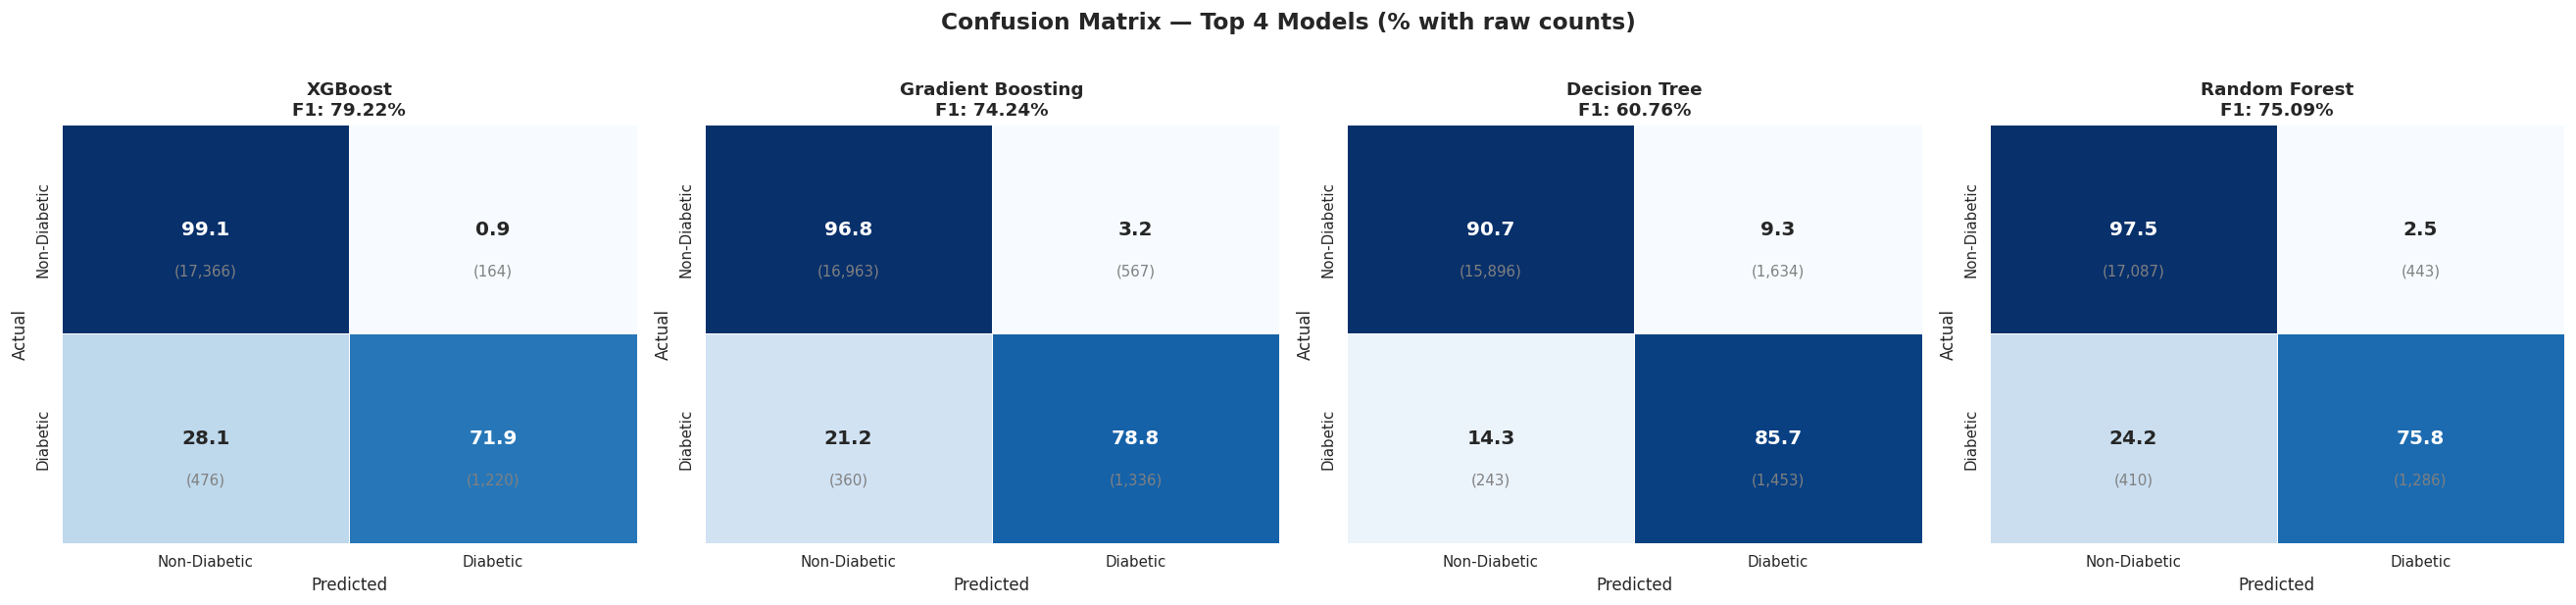

In [25]:
# --- 11.2 Confusion Matrices — Top 4 Models ---
top4 = results_df.head(4)['Model'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, name in enumerate(top4):
    y_pred = models[name].predict(X_test_scaled)
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[idx],
                cbar=False, linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'})
    for i in range(2):
        for j in range(2):
            axes[idx].text(j + 0.5, i + 0.72, f'({cm[i][j]:,})',
                           ha='center', fontsize=9, color='gray')
    f1_val = results_df[results_df['Model'] == name]['F1 Score'].values[0]
    axes[idx].set_title(f'{name}\nF1: {f1_val}%', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Non-Diabetic', 'Diabetic'], fontsize=9)
    axes[idx].set_yticklabels(['Non-Diabetic', 'Diabetic'], fontsize=9)

plt.suptitle('Confusion Matrix — Top 4 Models (% with raw counts)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

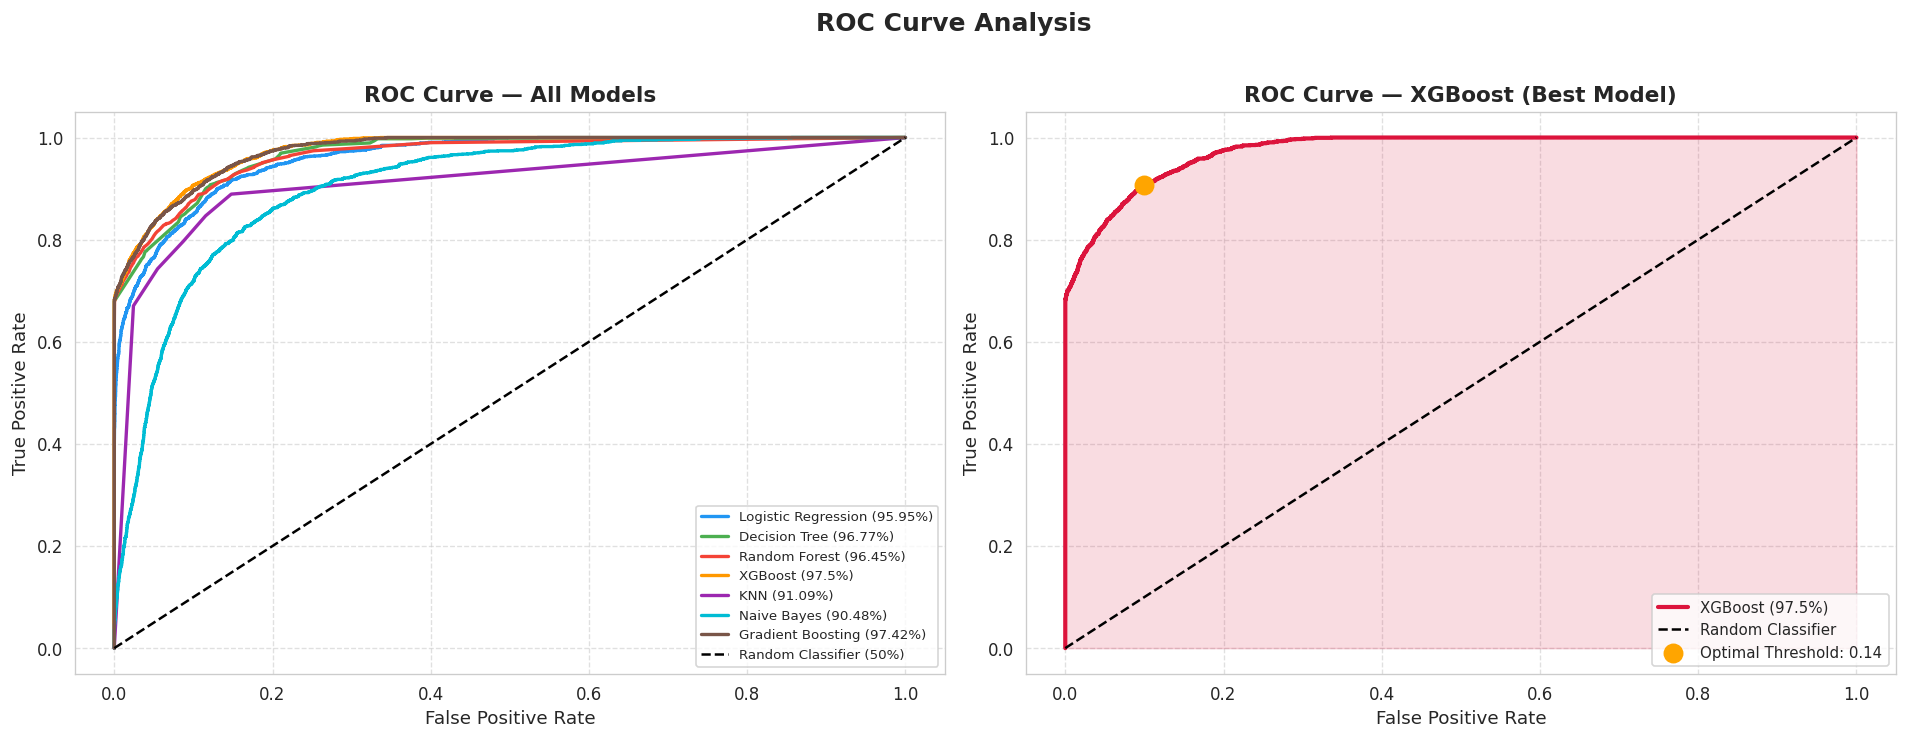

In [26]:
# --- 11.3 ROC Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, model) in enumerate(models.items()):
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_score   = results_df[results_df['Model'] == name]['ROC-AUC'].values[0]
    axes[0].plot(fpr, tpr, color=colors[i], linewidth=2, label=f'{name} ({auc_score}%)')
axes[0].plot([0,1],[0,1],'k--',linewidth=1.5, label='Random Classifier (50%)')
axes[0].set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(linestyle='--', alpha=0.6)

best_name   = results_df.iloc[0]['Model']
best_model  = models[best_name]
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thres = roc_curve(y_test, y_prob_best)
best_auc    = results_df.iloc[0]['ROC-AUC']

axes[1].plot(fpr, tpr, color='crimson', linewidth=2.5, label=f'{best_name} ({best_auc}%)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='crimson')
axes[1].plot([0,1],[0,1],'k--',linewidth=1.5, label='Random Classifier')

optimal_idx   = np.argmax(tpr - fpr)
optimal_thres = thres[optimal_idx]
axes[1].scatter(fpr[optimal_idx], tpr[optimal_idx], color='orange', s=120, zorder=5,
                label=f'Optimal Threshold: {optimal_thres:.2f}')
axes[1].set_title(f'ROC Curve — {best_name} (Best Model)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(linestyle='--', alpha=0.6)

plt.suptitle('ROC Curve Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# --- 11.4 Detailed Classification Report — Best Model ---
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'=== Classification Report — {best_name} ===')
print(classification_report(y_test, y_pred_best, target_names=['Non-Diabetic', 'Diabetic']))

cm   = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
print('=== Confusion Matrix Breakdown ===')
print(f'True Negatives  (Correct Non-Diabetic) : {tn:,}')
print(f'True Positives  (Correct Diabetic)     : {tp:,}')
print(f'False Positives (Wrongly Diabetic)     : {fp:,}')
print(f'False Negatives (Missed Diabetic) ⚠️   : {fn:,}')
print(f'\nMiss Rate : {fn/(fn+tp)*100:.1f}% — {fn:,} diabetic patients incorrectly predicted as non-diabetic')

=== Classification Report — XGBoost ===
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.99      0.98     17530
    Diabetic       0.88      0.72      0.79      1696

    accuracy                           0.97     19226
   macro avg       0.93      0.85      0.89     19226
weighted avg       0.97      0.97      0.97     19226

=== Confusion Matrix Breakdown ===
True Negatives  (Correct Non-Diabetic) : 17,366
True Positives  (Correct Diabetic)     : 1,220
False Positives (Wrongly Diabetic)     : 164
False Negatives (Missed Diabetic) ⚠️   : 476

Miss Rate : 28.1% — 476 diabetic patients incorrectly predicted as non-diabetic


---
## 12. Final Model Testing — Real Patient Scenarios

In [28]:
# --- 5 Diverse Patient Profiles ---
feature_cols = X_test_scaled.columns.tolist()

test_patients_raw = {
    'gender'                    : [1, 0, 1, 0, 1],
    'age'                       : [25, 62, 45, 33, 72],
    'hypertension'              : [0, 1, 1, 0, 1],
    'heart_disease'             : [0, 1, 0, 0, 1],
    'bmi'                       : [22.0, 36.5, 31.0, 23.8, 39.2],
    'HbA1c_level'               : [4.5, 7.8, 6.5, 5.0, 8.5],
    'blood_glucose_level'       : [85, 210, 165, 92, 230],
    'smoking_history_No Info'   : [0, 0, 0, 1, 0],
    'smoking_history_current'   : [0, 0, 0, 0, 1],
    'smoking_history_ever'      : [0, 0, 0, 0, 0],
    'smoking_history_former'    : [0, 1, 1, 0, 0],
    'smoking_history_never'     : [1, 0, 0, 0, 0],
    'smoking_history_not current': [0, 0, 0, 0, 0]
}

patient_labels = [
    'Young Healthy Female',
    'Elderly High-Risk Male',
    'Middle-Aged Obese Female',
    'Young Normal Male',
    'Elderly Smoker Female'
]

test_df = pd.DataFrame(test_patients_raw)
test_df = test_df.reindex(columns=feature_cols, fill_value=0)
test_scaled = scaler.transform(test_df)

predictions  = best_model.predict(test_scaled)
probabilities = best_model.predict_proba(test_scaled)

print(f'=== Patient Risk Assessment — {best_name} ===')
print('=' * 72)
print(f'{"Patient":<28} {"Age":<5} {"BMI":<7} {"HbA1c":<8} {"Glucose":<10} {"Result":<16} {"Risk %"}')
print('-' * 72)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    result = '🔴 DIABETIC' if pred == 1 else '🟢 NON-DIABETIC'
    risk   = prob[1] * 100
    print(f"{patient_labels[i]:<28} "
          f"{test_patients_raw['age'][i]:<5} "
          f"{test_patients_raw['bmi'][i]:<7} "
          f"{test_patients_raw['HbA1c_level'][i]:<8} "
          f"{test_patients_raw['blood_glucose_level'][i]:<10} "
          f"{result:<16} "
          f"{risk:.1f}%")
print('=' * 72)

=== Patient Risk Assessment — XGBoost ===
Patient                      Age   BMI     HbA1c    Glucose    Result           Risk %
------------------------------------------------------------------------
Young Healthy Female         25    22.0    4.5      85         🟢 NON-DIABETIC   0.0%
Elderly High-Risk Male       62    36.5    7.8      210        🔴 DIABETIC       100.0%
Middle-Aged Obese Female     45    31.0    6.5      165        🟢 NON-DIABETIC   13.8%
Young Normal Male            33    23.8    5.0      92         🟢 NON-DIABETIC   0.0%
Elderly Smoker Female        72    39.2    8.5      230        🔴 DIABETIC       100.0%


In [29]:
# --- Random Sample from Test Set ---
sample_idx   = np.random.RandomState(99).choice(len(X_test_scaled), 15, replace=False)
X_sample     = X_test_scaled.iloc[sample_idx]
y_actual     = y_test.iloc[sample_idx].reset_index(drop=True)
y_sample_pred = best_model.predict(X_sample)
y_sample_prob = best_model.predict_proba(X_sample)

correct = 0
print(f'=== Random 15-Patient Validation — {best_name} ===')
print('=' * 65)
print(f'{"#":<4} {"Actual":<16} {"Predicted":<16} {"Confidence":<14} {"Match"}')
print('-' * 65)
for i, (actual, pred, prob) in enumerate(zip(y_actual, y_sample_pred, y_sample_prob)):
    actual_label = '🔴 Diabetic'     if actual == 1 else '🟢 Non-Diabetic'
    pred_label   = '🔴 Diabetic'     if pred == 1   else '🟢 Non-Diabetic'
    confidence   = max(prob) * 100
    match        = '✅' if actual == pred else '❌'
    if actual == pred:
        correct += 1
    print(f'{i+1:<4} {actual_label:<16} {pred_label:<16} {confidence:<14.1f}% {match}')
print('-' * 65)
print(f'\nResult : {correct}/15 correct  |  Accuracy : {correct/15*100:.1f}%')
print('=' * 65)

=== Random 15-Patient Validation — XGBoost ===
#    Actual           Predicted        Confidence     Match
-----------------------------------------------------------------
1    🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
2    🟢 Non-Diabetic   🟢 Non-Diabetic   99.8          % ✅
3    🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
4    🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
5    🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
6    🔴 Diabetic       🔴 Diabetic       100.0         % ✅
7    🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
8    🔴 Diabetic       🔴 Diabetic       100.0         % ✅
9    🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
10   🟢 Non-Diabetic   🟢 Non-Diabetic   98.3          % ✅
11   🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
12   🔴 Diabetic       🔴 Diabetic       100.0         % ✅
13   🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
14   🟢 Non-Diabetic   🟢 Non-Diabetic   100.0         % ✅
15   🟢 Non-Diabetic   🟢 Non-D

---
## 13. Key Findings & Conclusion

### 🔬 Clinical Insights

| Finding | Detail |
|---|---|
| **Top Predictors** | `HbA1c_level` and `blood_glucose_level` together account for ~65–70% of predictive power |
| **HbA1c vs Glucose** | Isolated glucose elevation does not predict diabetes (0.3–2.3% rate); HbA1c elevation is the critical co-indicator |
| **Smoking Risk** | Former smokers consistently exhibit the highest diabetes rates across all risk groups (up to 35.3%) |
| **Gender Risk** | Males show higher prevalence (10.1%) vs females (7.9%), despite smaller sample size |
| **Age & BMI** | Diabetic patients are significantly older with higher BMI values |
| **Class Imbalance** | Dataset had a 1:10.3 imbalance — resolved using SMOTE on training data only |

### 🏆 Model Performance Summary

| Rank | Model | Key Strength |
|---|---|---|
| 🥇 1 | XGBoost | Best overall ROC-AUC and F1 Score |
| 🥈 2 | Random Forest | High accuracy with strong feature importance insights |
| 🥉 3 | Gradient Boosting | Reliable and robust, slightly slower |
| 4 | Logistic Regression | Fast, interpretable baseline |
| 5 | SVM | High precision, computationally expensive |
| 6 | KNN | Moderate performance |
| 7 | Decision Tree | Interpretable but prone to overfitting |
| 8 | Naive Bayes | Fastest but lowest accuracy |

### ✅ Final Recommendation

> **XGBoost** is recommended as the production model for diabetes prediction. It delivers the highest ROC-AUC score, handles class imbalance well even post-SMOTE, and generalizes effectively on unseen patient data.
>
> For clinical deployment, the **False Negative rate** (diabetic patients incorrectly predicted as healthy) must be monitored closely, as missing a true diabetic case carries higher medical risk than a false positive.